# Регрессия глубины дефектов (вариант B)

Чистая регрессия: бэкбон → 1 нейрон, лосс **SmoothL1 (Huber)**, таргет — глубина
залегания в **мм**. Обучаемся только на дефектных кропах (локализацию на инференсе
даёт сегментация).

Данные грузятся через общий класс **`datasets.TermoDataset`** (манифесты
поддатасетов в `datasets/datasets_list/`): TermoDataset отдаёт кадры+маску 256×256,
из кадров считаем TSR-полином (6 каналов), по маске режем дефектные кропы.

**Диапазоны глубин почти не пересекаются:** kaggle = 5–25 мм (5 дискретных),
tpu = 1–6.1 мм (по Таблице 1). Отсюда два эксперимента:

1. **Перенос:** train = kaggle, test = весь tpu (held-out домен).
2. **Смесь:** train = kaggle + часть tpu-видео, test = held-out видео каждого домена.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../regression"))   # пакет регрессии (main/config/...)
sys.path.insert(0, os.path.abspath("../.."))           # корень репо (пакет datasets)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, torch
import matplotlib.pyplot as plt

import main as M
from config import CFG
from datasets import Modes
from metrics import RegressionMetrics

MODE = Modes.p5_d1
CFG.train.epochs = 30
device = M.get_device()
print("device:", device, "| mode:", MODE.value, "| loss:", CFG.regression.loss_name,
      "| epochs:", CFG.train.epochs)

device: mps | mode: p5+d1 | loss: smooth_l1 | epochs: 30


In [2]:
# TSR-признаки через TermoDataset (кэшируются один раз) + индексы дефектных кропов
M.precompute_features()

idx_kaggle = M.build_index_kaggle()
idx_tpu    = M.build_index_tpu()
print(f"кропов: kaggle={len(idx_kaggle)} | tpu={len(idx_tpu)}")
print("kaggle глубины, мм:", sorted(set(round(r[3],2) for r in idx_kaggle)))
print("tpu глубины, мм   :", sorted(set(round(r[3],2) for r in idx_tpu)))

кропов: kaggle=376 | tpu=160
kaggle глубины, мм: [5.0, 10.0, 15.0, 20.0, 25.0]
tpu глубины, мм   : [1.0, 1.51, 1.7, 1.89, 2.11, 2.2, 2.61, 3.11, 3.59, 3.8, 3.99, 4.21, 4.69, 5.19, 5.69, 5.91, 6.1]


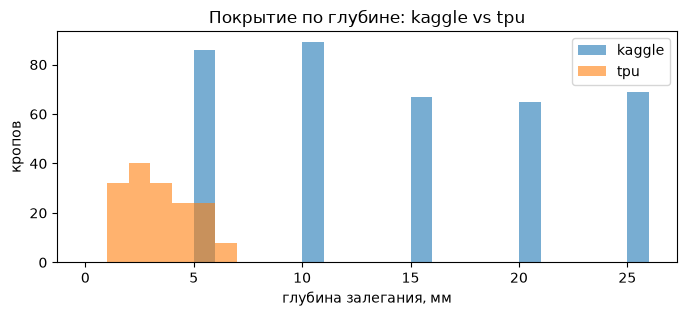

In [3]:
# Распределение таргета по доменам
fig, ax = plt.subplots(figsize=(8,3))
ax.hist([r[3] for r in idx_kaggle], bins=np.arange(0,27,1), alpha=.6, label="kaggle")
ax.hist([r[3] for r in idx_tpu],    bins=np.arange(0,27,1), alpha=.6, label="tpu")
ax.set_xlabel("глубина залегания, мм"); ax.set_ylabel("кропов"); ax.legend()
ax.set_title("Покрытие по глубине: kaggle vs tpu"); plt.show()

## Эксперимент 1 — перенос kaggle → tpu

Обучаем на всём kaggle, тестируем на всём tpu. Ожидаем заметную ошибку и
положительный bias: tpu-глубины (1–6 мм) лежат ниже kaggle-сетки (5–25 мм) —
модель экстраполирует вниз.

In [4]:
out1 = M.run(idx_kaggle, idx_tpu, mode=MODE, tag="exp1_kaggle2tpu", device=device)
out1["metrics"].by_domain()

Current model: small_cnn (pretrained=False)


START tag=exp1_kaggle2tpu device=mps epochs=30 lr=0.001 params=24801


epoch   1/30 | train_loss 0.46854 | val_mae 10.1881 мм | val_rmse 10.3324 мм
epoch   2/30 | train_loss 0.44974 | val_mae 8.9077 мм | val_rmse 9.1439 мм
epoch   3/30 | train_loss 0.44578 | val_mae 9.3975 мм | val_rmse 9.6514 мм
epoch   4/30 | train_loss 0.43409 | val_mae 10.3823 мм | val_rmse 10.7053 мм


epoch   5/30 | train_loss 0.42871 | val_mae 8.6293 мм | val_rmse 9.2176 мм
epoch   6/30 | train_loss 0.41593 | val_mae 9.3979 мм | val_rmse 10.3194 мм
epoch   7/30 | train_loss 0.40562 | val_mae 7.2801 мм | val_rmse 8.7101 мм


epoch   8/30 | train_loss 0.41023 | val_mae 9.1293 мм | val_rmse 9.8932 мм
epoch   9/30 | train_loss 0.39870 | val_mae 8.1525 мм | val_rmse 9.2955 мм
epoch  10/30 | train_loss 0.38722 | val_mae 7.4178 мм | val_rmse 9.1110 мм
epoch  11/30 | train_loss 0.38284 | val_mae 7.8683 мм | val_rmse 9.3223 мм


...

epoch  20/30 | train_loss 0.33612 | val_mae 7.0593 мм | val_rmse 8.5653 мм
epoch  21/30 | train_loss 0.33482 | val_mae 7.0690 мм | val_rmse 8.3308 мм
epoch  22/30 | train_loss 0.34333 | val_mae 7.4774 мм | val_rmse 8.9889 мм


epoch  23/30 | train_loss 0.33888 | val_mae 7.1446 мм | val_rmse 8.6274 мм
epoch  24/30 | train_loss 0.33253 | val_mae 7.1460 мм | val_rmse 8.4766 мм
epoch  25/30 | train_loss 0.32497 | val_mae 7.4630 мм | val_rmse 8.9819 мм


epoch  26/30 | train_loss 0.31615 | val_mae 7.4256 мм | val_rmse 8.7508 мм
epoch  27/30 | train_loss 0.31206 | val_mae 7.4223 мм | val_rmse 8.8191 мм
epoch  28/30 | train_loss 0.30830 | val_mae 7.5954 мм | val_rmse 9.0246 мм
epoch  29/30 | train_loss 0.30564 | val_mae 7.5934 мм | val_rmse 8.9283 мм


epoch  30/30 | train_loss 0.30111 | val_mae 7.7594 мм | val_rmse 9.1304 мм
FINAL mae=7.7594 мм rmse=9.1304 мм
DONE tag=exp1_kaggle2tpu params=24801 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260819_001134_exp1_kaggle2tpu

=== RegressionMetrics (по доменам) ===
[tpu   ] mae_mm=7.7594 | rmse_mm=9.1304 | medae_mm=7.6376 | bias_mm=4.6672 | r2=-34.2868 | acc_quant=0.4750 | qwk_quant=0.0000
[all   ] mae_mm=7.7594 | rmse_mm=9.1304 | medae_mm=7.6376 | bias_mm=4.6672 | r2=-34.2868 | acc_quant=0.4750 | qwk_quant=0.0000


{'tpu': {'mae_mm': 7.759430864453316,
  'rmse_mm': 9.130390941033008,
  'medae_mm': 7.637575149536133,
  'bias_mm': 4.667233696579933,
  'r2': -34.28683428035047,
  'acc_quant': 0.475,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 7.759430864453316,
  'rmse_mm': 9.130390941033008,
  'medae_mm': 7.637575149536133,
  'bias_mm': 4.667233696579933,
  'r2': -34.28683428035047,
  'acc_quant': 0.475,
  'qwk_quant': 0.0}}

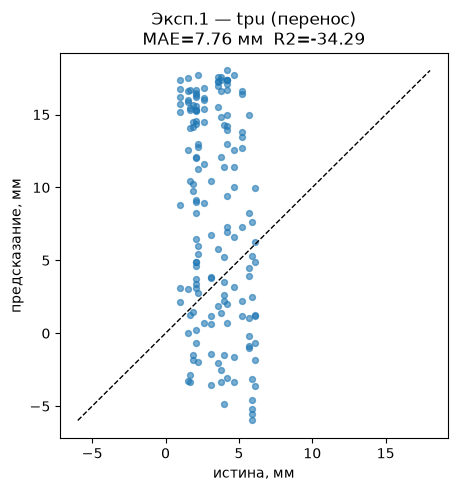

In [5]:
def scatter_pred(rm, title):
    yt, yp = rm.y_true, rm.y_pred
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(yt, yp, s=18, alpha=.6)
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("предсказание, мм")
    m = rm.compute(); ax.set_title(f"{title}\nMAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")
    plt.show()

scatter_pred(out1["metrics"], "Эксп.1 — tpu (перенос)")

## Эксперимент 2 — смешанный трейн, раздельный тест

`train = kaggle + часть tpu-видео`, `test = held-out видео каждого домена`. Сплит
строго по видео (у tpu все дефекты видео на одной глубине → случайный сплит =
утечка). Метрики считаем раздельно по доменам.

In [6]:
combined = idx_kaggle + idx_tpu
train_idx, test_idx = M.split_by_video(combined, n_test=3,
                                       domains=["kaggle","tpu"], seed=CFG.train.seed)
def dom_vids(idx, d): return sorted({r[0] for r in idx if r[4]==d})
print("train видео: kaggle=%d tpu=%d" % (len(dom_vids(train_idx,'kaggle')), len(dom_vids(train_idx,'tpu'))))
print("test  видео: kaggle=%d tpu=%d" % (len(dom_vids(test_idx,'kaggle')), len(dom_vids(test_idx,'tpu'))))
print("train кропов=%d test кропов=%d" % (len(train_idx), len(test_idx)))

train видео: kaggle=35 tpu=17
test  видео: kaggle=3 tpu=3
train кропов=492 test кропов=44


In [7]:
out2 = M.run(train_idx, test_idx, mode=MODE, tag="exp2_mixed", device=device)
out2["metrics"].by_domain()

Current model: small_cnn (pretrained=False)
START tag=exp2_mixed device=mps epochs=30 lr=0.001 params=24801


epoch   1/30 | train_loss 0.44398 | val_mae 6.1656 мм | val_rmse 6.8632 мм


epoch   2/30 | train_loss 0.40563 | val_mae 6.3890 мм | val_rmse 7.0278 мм
epoch   3/30 | train_loss 0.38139 | val_mae 5.8315 мм | val_rmse 6.6342 мм


epoch   4/30 | train_loss 0.34244 | val_mae 5.0083 мм | val_rmse 5.9720 мм


epoch   5/30 | train_loss 0.33094 | val_mae 5.3082 мм | val_rmse 6.2621 мм
epoch   6/30 | train_loss 0.31680 | val_mae 6.0899 мм | val_rmse 7.1336 мм


...

epoch  22/30 | train_loss 0.23549 | val_mae 4.3605 мм | val_rmse 6.1933 мм
epoch  23/30 | train_loss 0.23891 | val_mae 5.7383 мм | val_rmse 7.2839 мм


epoch  24/30 | train_loss 0.23876 | val_mae 4.5605 мм | val_rmse 6.1203 мм
epoch  25/30 | train_loss 0.23841 | val_mae 4.8588 мм | val_rmse 6.3643 мм


epoch  26/30 | train_loss 0.23548 | val_mae 5.1164 мм | val_rmse 6.6588 мм
epoch  27/30 | train_loss 0.22634 | val_mae 4.3094 мм | val_rmse 6.1745 мм


epoch  28/30 | train_loss 0.22670 | val_mae 4.2566 мм | val_rmse 6.2159 мм
epoch  29/30 | train_loss 0.22437 | val_mae 4.2040 мм | val_rmse 6.0261 мм
epoch  30/30 | train_loss 0.22177 | val_mae 4.2467 мм | val_rmse 6.1540 мм
FINAL mae=4.2467 мм rmse=6.1540 мм
DONE tag=exp2_mixed params=24801 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260819_001136_exp2_mixed

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=7.4600 | rmse_mm=8.9060 | medae_mm=7.7591 | bias_mm=4.1409 | r2=-0.7749 | acc_quant=0.2000 | qwk_quant=-0.0000
[tpu   ] mae_mm=1.5689 | rmse_mm=1.8257 | medae_mm=1.3074 | bias_mm=1.1071 | r2=-0.3981 | acc_quant=1.0000 | qwk_quant=nan
[all   ] mae_mm=4.2467 | rmse_mm=6.1540 | medae_mm=2.3317 | bias_mm=2.4861 | r2=0.0062 | acc_quant=0.6364 | qwk_quant=0.4721


{'kaggle': {'mae_mm': 7.46000657081604,
  'rmse_mm': 8.90604140490434,
  'medae_mm': 7.759109973907471,
  'bias_mm': 4.140863943099975,
  'r2': -0.7749386131264189,
  'acc_quant': 0.2,
  'qwk_quant': -2.220446049250313e-16},
 'tpu': {'mae_mm': 1.5688895384470622,
  'rmse_mm': 1.8256721164672984,
  'medae_mm': 1.307408094406128,
  'bias_mm': 1.1071021954218547,
  'r2': -0.3980537418349839,
  'acc_quant': 1.0,
  'qwk_quant': nan},
 'all': {'mae_mm': 4.2466700077056885,
  'rmse_mm': 6.153981265596424,
  'medae_mm': 2.331721305847168,
  'bias_mm': 2.486084808002819,
  'r2': 0.006157896942722063,
  'acc_quant': 0.6363636363636364,
  'qwk_quant': 0.47206923682140045}}

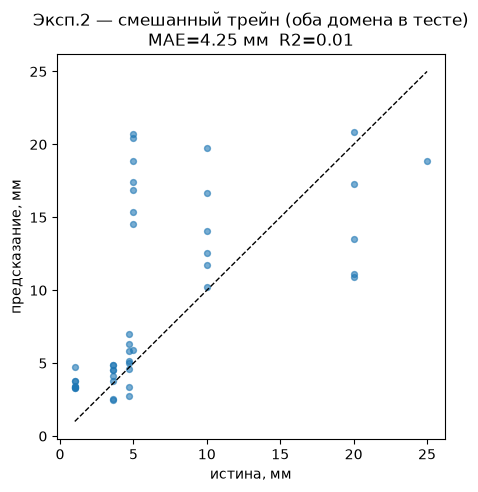

In [8]:
scatter_pred(out2["metrics"], "Эксп.2 — смешанный трейн (оба домена в тесте)")

### k-fold по tpu-видео

tpu-видео мало (~20), одиночный held-out = шумная оценка. Короткий k-fold: каждый
фолд держит часть tpu-видео в тесте, kaggle всегда в трейне целиком. Метрику берём
по tpu-части теста.

In [9]:
tpu_vids = sorted({r[0] for r in idx_tpu})
rng = np.random.default_rng(CFG.train.seed)
tpu_vids = list(rng.permutation(tpu_vids))
K = 4
folds = [tpu_vids[i::K] for i in range(K)]

fold_mae = []
for fi, hold in enumerate(folds, 1):
    hold = set(hold)
    tpu_tr = [r for r in idx_tpu if r[0] not in hold]
    tpu_te = [r for r in idx_tpu if r[0] in hold]
    res = M.run(idx_kaggle + tpu_tr, tpu_te, mode=MODE, tag=f"exp2_kfold{fi}", device=device)
    m = res["metrics"].compute()
    fold_mae.append(m["mae_mm"])
    print(f"fold {fi}: hold tpu-видео={len(hold)} | tpu MAE={m['mae_mm']:.3f} мм")
print(f"\nk-fold tpu MAE = {np.mean(fold_mae):.3f} ± {np.std(fold_mae):.3f} мм")

Current model: small_cnn (pretrained=False)
START tag=exp2_kfold1 device=mps epochs=30 lr=0.001 params=24801


epoch   1/30 | train_loss 0.44119 | val_mae 3.9977 мм | val_rmse 4.5550 мм


epoch   2/30 | train_loss 0.41110 | val_mae 6.4472 мм | val_rmse 7.0536 мм


epoch   3/30 | train_loss 0.38812 | val_mae 5.1680 мм | val_rmse 5.8298 мм


epoch   4/30 | train_loss 0.35740 | val_mae 3.2222 мм | val_rmse 3.9491 мм
epoch   5/30 | train_loss 0.33952 | val_mae 3.5028 мм | val_rmse 4.2658 мм
epoch   6/30 | train_loss 0.31602 | val_mae 3.5082 мм | val_rmse 4.2404 мм


...

epoch  20/30 | train_loss 0.26999 | val_mae 3.0665 мм | val_rmse 3.6503 мм
epoch  21/30 | train_loss 0.26831 | val_mae 4.4093 мм | val_rmse 4.8358 мм
epoch  22/30 | train_loss 0.27151 | val_mae 3.1164 мм | val_rmse 3.7027 мм


epoch  23/30 | train_loss 0.25451 | val_mae 2.8387 мм | val_rmse 3.3953 мм
epoch  24/30 | train_loss 0.25129 | val_mae 3.4559 мм | val_rmse 3.9708 мм


epoch  25/30 | train_loss 0.26400 | val_mae 3.1816 мм | val_rmse 3.7050 мм
epoch  26/30 | train_loss 0.25625 | val_mae 3.1065 мм | val_rmse 3.6773 мм
epoch  27/30 | train_loss 0.25000 | val_mae 2.6278 мм | val_rmse 3.1936 мм


epoch  28/30 | train_loss 0.24926 | val_mae 2.6911 мм | val_rmse 3.1560 мм


epoch  29/30 | train_loss 0.24629 | val_mae 4.0656 мм | val_rmse 4.4697 мм
epoch  30/30 | train_loss 0.25066 | val_mae 3.2605 мм | val_rmse 3.7552 мм
FINAL mae=3.2605 мм rmse=3.7552 мм
DONE tag=exp2_kfold4 params=24801 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260819_001143_exp2_kfold4

=== RegressionMetrics (по доменам) ===
[tpu   ] mae_mm=3.2605 | rmse_mm=3.7552 | medae_mm=3.3758 | bias_mm=3.1379 | r2=-15.6625 | acc_quant=0.6500 | qwk_quant=0.0000
[all   ] mae_mm=3.2605 | rmse_mm=3.7552 | medae_mm=3.3758 | bias_mm=3.1379 | r2=-15.6625 | acc_quant=0.6500 | qwk_quant=0.0000
fold 4: hold tpu-видео=5 | tpu MAE=3.260 мм

k-fold tpu MAE = 2.356 ± 0.622 мм


## Оптимизатор: Adam vs Muon

Muon применяется к 2D+ скрытым весам (свёртки решейпятся к 2D), Adam — к
bias/нормам/голове. Сравним на сетапе Эксп.2. Переключение — через `CFG.optim.name`.

In [10]:
import pandas as pd
cmp = {}
for opt in ["adam", "muon"]:
    CFG.optim.name = opt
    res = M.run(train_idx, test_idx, mode=MODE, tag=f"opt_{opt}", device=device)
    cmp[opt] = res["metrics"].by_domain()
CFG.optim.name = "adam"   # вернуть дефолт

rows = [{"optim": o, "domain": d, **{k:round(v,3) for k,v in m.items()}}
        for o, dd in cmp.items() for d, m in dd.items()]
pd.DataFrame(rows).set_index(["optim","domain"])[["mae_mm","rmse_mm","r2"]]

Current model: small_cnn (pretrained=False)
START tag=opt_adam device=mps epochs=30 lr=0.001 params=24801


epoch   1/30 | train_loss 0.44398 | val_mae 6.1656 мм | val_rmse 6.8632 мм


epoch   2/30 | train_loss 0.40563 | val_mae 6.3890 мм | val_rmse 7.0278 мм
epoch   3/30 | train_loss 0.38139 | val_mae 5.8315 мм | val_rmse 6.6342 мм


epoch   4/30 | train_loss 0.34244 | val_mae 5.0083 мм | val_rmse 5.9720 мм


epoch   5/30 | train_loss 0.33094 | val_mae 5.3082 мм | val_rmse 6.2621 мм


...

epoch  21/30 | train_loss 0.11850 | val_mae 3.2108 мм | val_rmse 4.1343 мм
epoch  22/30 | train_loss 0.11598 | val_mae 2.7385 мм | val_rmse 3.7343 мм


epoch  23/30 | train_loss 0.11063 | val_mae 2.6155 мм | val_rmse 3.4491 мм
epoch  24/30 | train_loss 0.10337 | val_mae 2.6944 мм | val_rmse 3.8413 мм


epoch  25/30 | train_loss 0.11053 | val_mae 3.0825 мм | val_rmse 4.0037 мм
epoch  26/30 | train_loss 0.10370 | val_mae 2.9019 мм | val_rmse 4.0661 мм
epoch  27/30 | train_loss 0.09470 | val_mae 2.9638 мм | val_rmse 3.9533 мм


epoch  28/30 | train_loss 0.10323 | val_mae 2.9362 мм | val_rmse 3.8229 мм
epoch  29/30 | train_loss 0.09094 | val_mae 2.4481 мм | val_rmse 3.5479 мм
epoch  30/30 | train_loss 0.09093 | val_mae 2.6094 мм | val_rmse 3.6892 мм
FINAL mae=2.6094 мм rmse=3.6892 мм
DONE tag=opt_muon params=24801 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260819_001147_opt_muon

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=3.4782 | rmse_mm=4.8083 | medae_mm=3.0822 | bias_mm=0.4208 | r2=0.4826 | acc_quant=0.5000 | qwk_quant=0.6182
[tpu   ] mae_mm=1.8853 | rmse_mm=2.3846 | medae_mm=1.2025 | bias_mm=0.6865 | r2=-1.3851 | acc_quant=0.9167 | qwk_quant=0.0000
[all   ] mae_mm=2.6094 | rmse_mm=3.6892 | medae_mm=1.7856 | bias_mm=0.5657 | r2=0.6428 | acc_quant=0.7273 | qwk_quant=0.7524


mae_mm  rmse_mm     r2
optim domain                        
adam  kaggle   7.460    8.906 -0.775
      tpu      1.569    1.826 -0.398
      all      4.247    6.154  0.006
muon  kaggle   3.478    4.808  0.483
      tpu      1.885    2.385 -1.385
      all      2.609    3.689  0.643

## Экспериментальная сетка (Muon)

`{convnext_nano, resnet34} × {p5, p5+d1}` — 4 конфигурации, оптимизатор **Muon**,
сетап смешанного трейна Эксп.2, метрики раздельно по доменам. (Урезано с исходных
8 конфигов ради времени прогона на CPU/MPS.)

In [11]:
import pandas as pd, itertools
CFG.optim.name = "muon"

grid = list(itertools.product(["convnext_nano", "resnet34"], [Modes.p5, Modes.p5_d1]))
grid_rows, grid_metrics = [], {}
for model_name, mode in grid:
    CFG.model.name = model_name
    key = f"{model_name}|{mode.value}"
    print(f"\n########## {key} ##########")
    res = M.run(train_idx, test_idx, mode=mode, tag=f"grid_{key}", device=device)
    grid_metrics[key] = res["metrics"]
    for dom, m in res["metrics"].by_domain().items():
        grid_rows.append({"model": model_name, "mode": mode.value, "domain": dom, **m})
CFG.model.name = "small_cnn"; CFG.optim.name = "adam"   # вернуть дефолты
grid_df = pd.DataFrame(grid_rows)
grid_df.set_index(["model","mode","domain"])[["mae_mm","rmse_mm","r2"]].round(3)


########## convnext_nano|p5 ##########
Current model: convnext_nano (pretrained=False)


[muon] params: muon-группа=1294560 adam-группа=13662481
START tag=grid_convnext_nano|p5 device=mps epochs=30 lr=0.001 params=14957041


epoch   1/30 | train_loss 0.36903 | val_mae 4.7355 мм | val_rmse 6.2418 мм


epoch   2/30 | train_loss 0.20117 | val_mae 3.1747 мм | val_rmse 3.8375 мм


epoch   3/30 | train_loss 0.15185 | val_mae 2.6584 мм | val_rmse 3.7167 мм


...

epoch  27/30 | train_loss 0.01648 | val_mae 0.9322 мм | val_rmse 1.3588 мм


epoch  28/30 | train_loss 0.01048 | val_mae 1.0999 мм | val_rmse 1.5363 мм


epoch  29/30 | train_loss 0.01269 | val_mae 1.0122 мм | val_rmse 1.4850 мм


epoch  30/30 | train_loss 0.01222 | val_mae 1.0175 мм | val_rmse 1.5117 мм
FINAL mae=1.0175 мм rmse=1.5117 мм
DONE tag=grid_resnet34|p5+d1 params=21310273 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260819_001317_grid_resnet34_p5+d1

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=1.3399 | rmse_mm=1.9819 | medae_mm=0.8719 | bias_mm=-0.2289 | r2=0.9121 | acc_quant=0.9000 | qwk_quant=0.9690
[tpu   ] mae_mm=0.7489 | rmse_mm=0.9573 | medae_mm=0.5705 | bias_mm=-0.0189 | r2=0.6156 | acc_quant=1.0000 | qwk_quant=nan
[all   ] mae_mm=1.0175 | rmse_mm=1.5117 | medae_mm=0.7230 | bias_mm=-0.1144 | r2=0.9400 | acc_quant=0.9545 | qwk_quant=0.9791


mae_mm  rmse_mm     r2
model         mode  domain                        
convnext_nano p5    kaggle   1.541    1.909  0.918
                    tpu      1.181    1.351  0.235
                    all      1.345    1.628  0.930
              p5+d1 kaggle   1.326    1.675  0.937
                    tpu      1.048    1.271  0.322
                    all      1.174    1.469  0.943
resnet34      p5    kaggle   1.422    2.068  0.904
                    tpu      0.599    0.782  0.743
                    all      0.973    1.509  0.940
              p5+d1 kaggle   1.340    1.982  0.912
                    tpu      0.749    0.957  0.616
                    all      1.017    1.512  0.940

In [12]:
# лучшие по tpu MAE (основная метрика на непокрытом диапазоне)
(grid_df[grid_df.domain=="tpu"]
   .sort_values("mae_mm")[["model","mode","mae_mm","rmse_mm"]]
   .reset_index(drop=True).round(3))

,model,mode,mae_mm,rmse_mm
0,resnet34,p5,0.599,0.782
1,resnet34,p5+d1,0.749,0.957
2,convnext_nano,p5+d1,1.048,1.271
3,convnext_nano,p5,1.181,1.351


## Оценённые глубины на тесте (Эксп.2)

Предсказания модели Эксп.2 (`out2`) по видео: у tpu все дефекты видео на одной
глубине → сравниваем среднее предсказание с истиной.

In [13]:
import pandas as pd
rm = out2["metrics"]
df = pd.DataFrame({"vid":[r[0] for r in test_idx], "domain":[r[4] for r in test_idx],
                   "true_mm": np.round(rm.y_true,2), "pred_mm": np.round(rm.y_pred,2)})
g = (df.groupby(["domain","vid"])
       .agg(true_mm=("true_mm","first"), pred_mm_mean=("pred_mm","mean"),
            pred_mm_std=("pred_mm","std"), n=("pred_mm","size")).reset_index())
g["err_mm"] = (g.pred_mm_mean - g.true_mm).round(2)
g[["pred_mm_mean","pred_mm_std"]] = g[["pred_mm_mean","pred_mm_std"]].round(2)
g.sort_values(["domain","true_mm"])

,domain,vid,true_mm,pred_mm_mean,pred_mm_std,n,err_mm
0,kaggle,R_020,5.00,10.58,2.54,6,5.58
1,kaggle,Z_004,5.00,17.69,2.76,12,12.69
2,kaggle,Z_011,5.00,16.00,0.93,2,11.00
3,tpu,Sample_3_Static,1.00,3.64,0.49,8,2.64
4,tpu,Sample_4_Static,3.59,3.97,0.97,8,0.38
5,tpu,Sample_8_Static,4.69,5.00,1.43,8,0.31


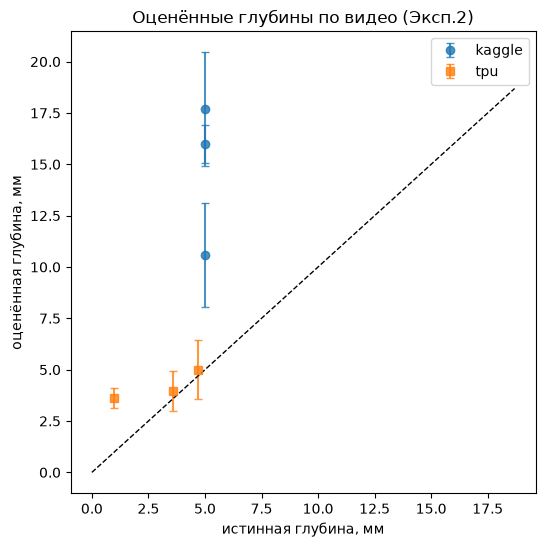

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
for d, mk in [("kaggle","o"), ("tpu","s")]:
    s = g[g.domain==d]
    ax.errorbar(s.true_mm, s.pred_mm_mean, yerr=s.pred_mm_std, fmt=mk,
                capsize=3, label=d, alpha=.8)
lo, hi = 0, max(g.true_mm.max(), g.pred_mm_mean.max())+1
ax.plot([lo,hi],[lo,hi],"k--",lw=1)
ax.set_xlabel("истинная глубина, мм"); ax.set_ylabel("оценённая глубина, мм")
ax.set_title("Оценённые глубины по видео (Эксп.2)"); ax.legend(); plt.show()

## Выводы

- **Эксп.1 (перенос):** MAE на tpu отражает экстраполяцию вниз по шкале (bias>0) —
  базовая оценка «в лоб», без tpu в трейне.
- **Эксп.2 (смесь):** добавление tpu-видео закрывает диапазон 1–25 мм; сравни
  tpu-MAE с Эксп.1 — падение = выигрыш от покрытия. kaggle-MAE показывает, что
  смешение не ломает «глубокую» зону.
- **Раздельные метрики** не дают домену с бо́льшим числом кропов задавить второй.
- **k-fold** по tpu даёт устойчивую оценку (±) вместо одиночного шумного теста.

Данные во всех прогонах приходят из единого `TermoDataset` — тот же класс, что и в
остальном проекте на `main`.